# OLS

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
# ============================================================
# 1. SELECT DATA
# ============================================================

# Feature
X = ins_data["bmi"]

# Target
y = ins_data["charges"]


In [38]:
X

0       27.900
1       33.770
2       33.000
3       22.705
4       28.880
         ...  
1333    30.970
1334    31.920
1335    36.850
1336    25.800
1337    29.070
Name: bmi, Length: 1338, dtype: float64

In [39]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [33]:
# ============================================================
# 2. CALCULATE MEANS
# ============================================================

x_mean = X.mean()
y_mean = y.mean()

print("Mean BMI:", x_mean)
print("Mean Charges:", y_mean)

Mean BMI: 30.66339686098655
Mean Charges: 13270.422265141257


In [34]:
# ============================================================
# 3. CALCULATE DEVIATIONS FROM MEAN
# ============================================================

x_deviation = X - x_mean
y_deviation = y - y_mean

In [36]:
x_deviation

0      -2.763397
1       3.106603
2       2.336603
3      -7.958397
4      -1.783397
          ...   
1333    0.306603
1334    1.256603
1335    6.186603
1336   -4.863397
1337   -1.593397
Name: bmi, Length: 1338, dtype: float64

In [37]:
y_deviation

0        3614.501735
1      -11544.869965
2       -8820.960265
3        8714.048345
4       -9403.567065
            ...     
1333    -2669.873965
1334   -11064.441465
1335   -11640.588765
1336   -11262.477265
1337    15870.938035
Name: charges, Length: 1338, dtype: float64

In [40]:
# ============================================================
# 4. CALCULATE NUMERATOR OF OLS SLOPE
# ============================================================
#
# Σ (xᵢ - x̄)(yᵢ - ȳ)
#

numerator = np.sum(
    x_deviation * y_deviation
)

print("Numerator:", numerator)


Numerator: 19583446.017992727


In [41]:
# ============================================================
# 5. CALCULATE DENOMINATOR OF OLS SLOPE
# ============================================================
#
# Σ (xᵢ - x̄)²
#

denominator = np.sum(
    x_deviation ** 2
)

print("Denominator:", denominator)

Denominator: 49720.20038626681


In [42]:
# ============================================================
# 6. CALCULATE SLOPE m
# ============================================================
#
#              Σ(xᵢ-x̄)(yᵢ-ȳ)
#       m = -----------------------
#              Σ(xᵢ-x̄)²
#

m = numerator / denominator

print("Slope m:", m)

Slope m: 393.8730307973952


In [43]:
# ============================================================
# 7. CALCULATE INTERCEPT b
# ============================================================
#
#       b = ȳ - m x̄
#

b = y_mean - m * x_mean

print("Intercept b:", b)

Intercept b: 1192.9372089611516


In [44]:
# ============================================================
# 8. FINAL OLS EQUATION
# ============================================================

print("\nFinal OLS equation:")

print(
    f"charges = {m:.4f} × BMI + {b:.4f}"
)


Final OLS equation:
charges = 393.8730 × BMI + 1192.9372


In [45]:
# ============================================================
# 9. MAKE PREDICTIONS
# ============================================================

y_pred = m * X + b

In [47]:
y_pred

0       12181.994768
1       14494.029459
2       14190.747225
3       10135.824373
4       12567.990338
            ...     
1333    13391.184973
1334    13765.364352
1335    15707.158394
1336    11354.861404
1337    12642.826214
Name: bmi, Length: 1338, dtype: float64

In [46]:
# ============================================================
# 10. CALCULATE RESIDUALS
# ============================================================
#
#       eᵢ = yᵢ - ŷᵢ
#

residuals = y - y_pred

In [48]:
residuals

0        4702.929232
1      -12768.477159
2       -9741.285225
3       11848.646237
4       -8701.135138
            ...     
1333    -2790.636673
1334   -11559.383552
1335   -14077.324894
1336    -9346.916404
1337    16498.534086
Length: 1338, dtype: float64

In [49]:
# ============================================================
# 11. CALCULATE SQUARED ERRORS
# ============================================================

squared_errors = residuals ** 2

In [50]:
squared_errors

0       2.211754e+07
1       1.630340e+08
2       9.489264e+07
3       1.403904e+08
4       7.570975e+07
            ...     
1333    7.787653e+06
1334    1.336193e+08
1335    1.981711e+08
1336    8.736485e+07
1337    2.722016e+08
Length: 1338, dtype: float64

In [51]:
# ============================================================
# 12. CALCULATE MSE
# ============================================================

mse = np.mean(
    squared_errors
)

print("\nMSE:", mse)


MSE: 140777900.09850758


In [52]:
# ============================================================
# 13. CALCULATE RSS
# ============================================================
#
# RSS = Σ(yᵢ - ŷᵢ)²
#

rss = np.sum(
    squared_errors
)

print("RSS:", rss)

RSS: 188360830331.80316


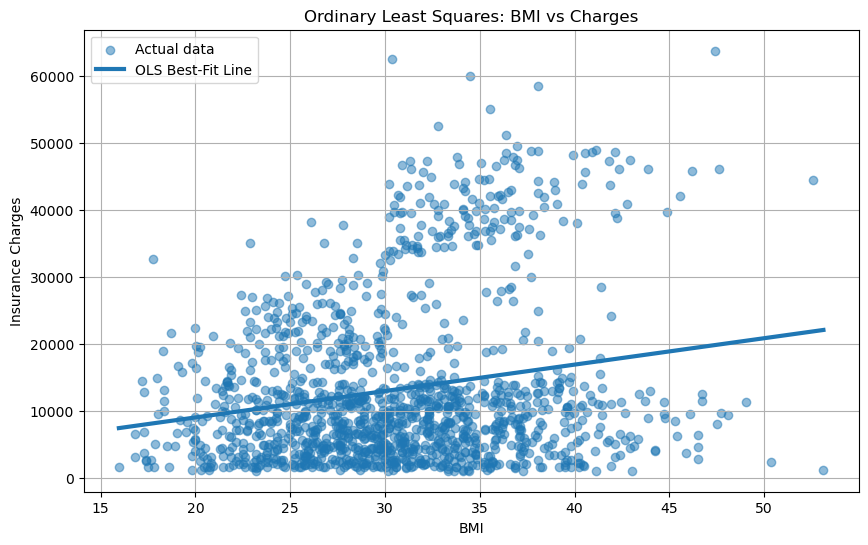

In [53]:
# ============================================================
# 14. VISUALIZE THE OLS BEST-FIT LINE
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    alpha=0.5,
    label="Actual data"
)

# Smooth x values for drawing line
x_line = np.linspace(
    X.min(),
    X.max(),
    200
)

# OLS predictions for line
y_line = m * x_line + b

plt.plot(
    x_line,
    y_line,
    linewidth=3,
    label="OLS Best-Fit Line"
)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.title(
    "Ordinary Least Squares: BMI vs Charges"
)

plt.legend()
plt.grid(True)

plt.show()


In [54]:
# ============================================================
# 15. VERIFY WITH SKLEARN
# ============================================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X.to_frame(),
    y
)

print("\nSklearn slope:", model.coef_[0])
print("Manual OLS slope:", m)

print("\nSklearn intercept:", model.intercept_)
print("Manual OLS intercept:", b)


Sklearn slope: 393.873030797395
Manual OLS slope: 393.8730307973952

Sklearn intercept: 1192.9372089611552
Manual OLS intercept: 1192.9372089611516
